### Exercise: **Bayesian** Coverage and Loss of Identifiability in NV Center ODMR

The problem to solve is the same as last week. For reference it's reported hereafter:

**The Physics Context:**
In quantum sensing, Nitrogen-Vacancy (NV) centers in diamond are read out using Optically Detected Magnetic Resonance (ODMR). You sweep a microwave frequency across the resonance and count the emitted photons. At the resonance frequency, the fluorescence drops, creating a "dip" in the spectrum.

To make the numerics manageable, our variable $\nu$ represents the **detuning** (in MHz) from the expected resonance (which is typically ~2.87 GHz). Therefore, a sweep from -5 to +5 means we are sweeping $\pm 5$ MHz around the center.

**The Statistical Model:**
Because we are counting independent photons, the number of observed photons $N_i$ at each discrete frequency point $\nu_i$ follows a Poisson distribution. The expected rate $\lambda(\nu_i)$ is modeled as a constant background $B$ minus a Lorentzian dip of amplitude $A$ (the contrast) and width $\gamma$:
$$\lambda(\nu_i) = B - A \frac{\gamma^2}{(\nu_i - \nu_0)^2 + \gamma^2}$$

The physical meaning and typical values of the parameters for our toy model are:
* **$B$ (Background):** Base photon counts per measurement point (True value = 1000).
* **$A$ (Amplitude/Contrast):** The depth of the dip in photon counts.
* **$\nu_0$ (Center):** The true resonance detuning (True value = 0.0 MHz).
* **$\gamma$ (Linewidth):** The width of the resonance (True value = 1.0 MHz).

**The Goal:**
If the true contrast $A$ is very weak, the signal gets buried in the Poisson noise ($\sqrt{B}$). In this regime, the linewidth $\gamma$ becomes completely unconstrained (a flat likelihood). This is called a "loss of identifiability."

Your goal is to obtain the 2D **Bayesian Credible Region** of $(A, \gamma)$ for three datasets generated with the three scenarios: a "Strong Signal" ($A=500$), a "Weak Signal" ($A=100$), and a "Very Weak Signal" ($A=20$).

**Step-by-Step Instructions:**

1. **The Generative Model & Likelihood:** * Write a Python function `rate_model(nu, B, A, nu0, gamma)` that returns the expected photon rate.
   * Write a function to generate toy datasets with Poisson fluctuations for the number of photons at 50 discrete points of the frequency detuning $\nu$ between -5 and 5.
   * Write a Log-Likelihood function for the Poisson data. (Note: for MCMC, we need the positive Log-Likelihood, not the Negative Log-Likelihood).

2. **The Prior & Posterior:**
   * Define a `log_prior(theta)` function for your parameter vector $\theta = (B, A, \nu_0, \gamma)$. You can set uniform priors within physically sensible bounds on the parameters. Return `0.0` if inside bounds, and `-np.inf` if outside.
   * Define a `log_posterior(theta, nu_data, N_data)` function that computes the sum of the prior and the log-likelihood.

3. **Setting up the MCMC Sampler (`emcee`):**
   * Choose the number of walkers (e.g., 32) and the number of steps (e.g., 3000).
   * Initialize the starting positions of the walkers using small random offsets around a reasonable initial guess.
   * Instantiate the `emcee.EnsembleSampler` and run the MCMC chain for your dataset.

4. **Extracting Samples and Visualizing:**
   * Discard the initial "burn-in" steps (e.g., the first 500 steps) to ensure the walkers have converged.
   * Flatten the chain to combine all walkers into a single list of samples.
   * Use the `corner` package to plot the posterior distributions for the POIs. Look at the 1D marginals and the 2D credible regions.

5. **Scanning the Contrast (The Core Task):**
   * Generate three separate datasets representing the three scenarios: a "Strong Signal" ($A=500$), a "Weak Signal" ($A=100$), and a "Very Weak Signal" ($A=20$).
   * Run the MCMC sampler and generate the corner plot for each of the three datasets.
   * **Question to answer:** Compare the 2D credible contours of $(A, \gamma)$ across the three scenarios. How does the Bayesian framework naturally handle the "loss of identifiability" when the signal becomes extremely weak compared to the frequentist profile likelihood?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.stats import poisson

# ==========================================
# GENERATIVE MODEL & LIKELIHOOD
# ==========================================

def rate_model(nu, B, A, nu0, gamma):
    """Lorentzian dip on a constant background."""
    return B - A * (gamma**2 / ((nu - nu0)**2 + gamma**2))

def generate_toy(nu, B, A, nu0, gamma):
    """Generates a toy dataset with Poisson fluctuations."""
    expected_rate = rate_model(nu, B, A, nu0, gamma)
    # Ensure physical rates (no negative expected photons)
    expected_rate = np.maximum(expected_rate, 1e-6)
    return np.random.poisson(expected_rate)

def create_nll(nu_data, N_data):
    """Creates a custom Poisson NLL function bound to specific data."""
    def nll(B, A, nu0, gamma):
        lam = rate_model(nu_data, B, A, nu0, gamma)
        lam = np.maximum(lam, 1e-6) # Protect against log(0) or negative rates

        # Calculate the negative log-likelihood using scipy
        return -np.sum(poisson.logpmf(N_data, mu=lam))

    return nll

Text(0, 0.5, 'Photon Counts')

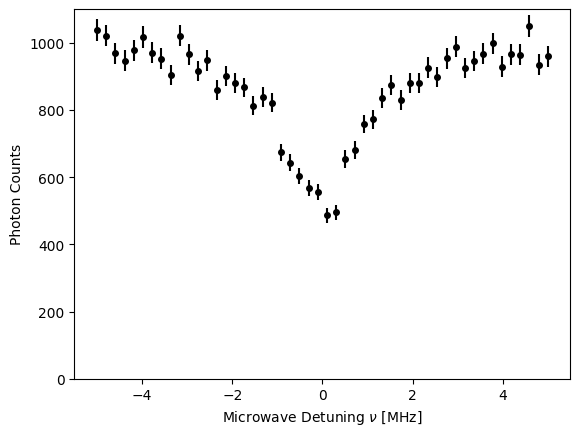

In [ ]:
nu_sweep = np.linspace(-5, 5, 50)
B_true, nu0_true, gamma_true = 1000.0, 0.0, 1.0

N_strong = generate_toy(nu_sweep, B_true, A=500, nu0=nu0_true, gamma=gamma_true)
plt.errorbar(nu_sweep, N_strong, yerr=np.sqrt(N_strong), fmt='ko', markersize=4, label='Toy Data')
plt.ylim(0, 1100)
plt.xlabel("Microwave Detuning $\\nu$ [MHz]")
plt.ylabel("Photon Counts")